In [10]:
import numpy as np
import pandas as pd
import os
import pickle
import warnings
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


# ============================================================
# ===================== FEATURE EXTRACTION ===================
# ============================================================

FEATURE_ORDER = [
    'mean', 'var', 'skew', 'kurt',
    'q10', 'q25', 'q50', 'q75', 'q90',
    'entropy'
]

def extract_features(scores):
    scores = np.ravel(scores)

    feats = {
        'mean': np.mean(scores),
        'var': np.var(scores),
        'skew': skew(scores),
        'kurt': kurtosis(scores),
        'q10': np.quantile(scores, 0.1),
        'q25': np.quantile(scores, 0.25),
        'q50': np.quantile(scores, 0.5),
        'q75': np.quantile(scores, 0.75),
        'q90': np.quantile(scores, 0.9),
    }

    hist, _ = np.histogram(scores, bins=20, density=True)
    hist += 1e-12
    feats["entropy"] = entropy(hist)

    return np.array([feats[k] for k in FEATURE_ORDER])


# ============================================================
# ========================= APP ==============================
# ============================================================

def generate_artificial_prevalences(n_prev=19, repeats=2):
    prevalences = np.linspace(0.05, 0.95, n_prev)
    return [[1-p, p] for p in prevalences] * repeats

def sample_with_prevalence(y, prevalence, batch_size):
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    n_pos = int(batch_size * prevalence[1])
    n_neg = batch_size - n_pos

    pos = np.random.choice(pos_idx, n_pos, replace=True)
    neg = np.random.choice(neg_idx, n_neg, replace=True)

    idx = np.concatenate([pos, neg])
    np.random.shuffle(idx)
    return idx

class APP:
    def __init__(self, batch_size=100, n_prev=19, repeats=2, seed=42):
        self.batch_size = batch_size
        self.prevalences = generate_artificial_prevalences(n_prev, repeats)
        np.random.seed(seed)

    def split(self, X, y):
        for prev in self.prevalences:
            idx = sample_with_prevalence(y, prev, self.batch_size)
            yield idx, prev


# ============================================================
# ======================== DY S ==============================
# ============================================================

def hellinger_distance(p, q):
    p = p / (p.sum() + 1e-12)
    q = q / (q.sum() + 1e-12)
    return (1 / np.sqrt(2)) * np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2))

def dys_quantifier(scores_batch, scores_train, y_train):
    """DyS via histogram-matching (Hellinger minimization)."""

    pos_scores = scores_train[y_train == 1]
    neg_scores = scores_train[y_train == 0]

    h_batch, _ = np.histogram(scores_batch, bins=20, density=True)
    h_pos, _ = np.histogram(pos_scores, bins=20, density=True)
    h_neg, _ = np.histogram(neg_scores, bins=20, density=True)

    def mixture(prev):
        return (1-prev) * h_neg + prev * h_pos

    grid = np.linspace(0, 1, 1001)
    best_prev = min(grid, key=lambda p: hellinger_distance(h_batch, mixture(p)))

    return float(best_prev)


# ============================================================
# =============== TREINAR REGRESSOR MOSS GIANTE ==============
# ============================================================

def load_moss_regressor(pkl_path):
    with open(pkl_path, "rb") as f:
        synthetic_dists = pickle.load(f)

    Xf, Y = [], []
    for key, curves in synthetic_dists.items():
        all_scores = np.vstack(curves)[:, 0]
        feats = extract_features(all_scores)

        Xf.append(feats)
        Y.append(key[0] if isinstance(key, tuple) else key)

    Xf = np.vstack(Xf)
    Y = np.array(Y)

    reg = RandomForestRegressor(n_estimators=300, random_state=42)
    reg.fit(Xf, Y)
    return reg


# ============================================================
# ============== CARREGAR DATASETS REAIS =====================
# ============================================================

def load_csv_dataset(path):
    df = pd.read_csv(path)

    if "y" in df.columns:
        y = df["y"].values
        X = df.drop(columns=["y"]).values
    else:
        y = df.iloc[:, -1].values
        X = df.iloc[:, :-1].values

    if len(np.unique(y)) > 2:
        y = (y == np.max(y)).astype(int)

    return X, y


# ============================================================
# ====================== AVALIAÇÃO ===========================
# ============================================================

def avaliar_dataset(ds_name, reg_moss, app, root):
    path = os.path.join(root, ds_name)
    X, y = load_csv_dataset(path)

    X = StandardScaler().fit_transform(X)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

    clf = RandomForestClassifier(n_estimators=300, random_state=42)
    clf.fit(Xtr, ytr)

    train_scores = clf.predict_proba(Xtr)[:, 1]

    rows = []

    for idx, prev_real in app.split(Xte, yte):
        Xb = Xte[idx]
        yb = yte[idx]

        scores = clf.predict_proba(Xb)[:, 1]
        feats, feat_names = extract_features(
            scores,
            pos_scores=train_scores[ytr == 1],
            neg_scores=train_scores[ytr == 0]
        )

        feats = feats.reshape(1, -1)

        # MOSS regressor
        prev_moss = reg_moss.predict(feats)[0]

        # DyS
        prev_dys = dys_quantifier(scores_batch=scores, scores_train=train_scores, y_train=ytr)

        rows.append({
            "dataset": ds_name,
            "prevalencia_real": np.mean(yb),
            "erro_moss": abs(prev_moss - np.mean(yb)),
            "erro_dys": abs(prev_dys - np.mean(yb)),
            "n_amostras": len(yb),
            "var_scores": np.var(scores),
            "entropy": extract_features(scores)[-1]
        })

    return rows


# ============================================================
# ====================== LOOP GLOBAL ==========================
# ============================================================

moss_folder = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss"
datasets_root = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary"

pkls = [
    os.path.join(moss_folder, f)
    for f in os.listdir(moss_folder)
    if f.endswith(".pkl") and "gigante" in f.lower()
]

datasets = sorted([f for f in os.listdir(datasets_root) if f.endswith(".csv")])

app = APP(batch_size=100, n_prev=19, repeats=2, seed=42)

all_rows = []

for pkl_path in pkls:
    print(f"\nTreinando regressor com {pkl_path}")
    reg_moss = load_moss_regressor(pkl_path)

    for ds in datasets:
        print(f"→ Dataset: {ds}")
        rows = avaliar_dataset(ds, reg_moss, app, datasets_root)
        all_rows.extend(rows)

df = pd.DataFrame(all_rows)
df.to_csv("tabela_final_moss_dys.csv", index=False)

print("\nTabela salva como tabela_final_moss_dys.csv")


Treinando regressor com /var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss/moss_GIGANTE.pkl
→ Dataset: 1460_banana.csv


TypeError: extract_features() got an unexpected keyword argument 'pos_scores'

In [15]:
import pandas as pd

df = pd.read_csv("tabela_final_moss_dys.csv")

In [4]:
df_moss_ruim = df.sort_values("erro_moss", ascending=False).head(20)
df_moss_bom  = df.sort_values("erro_moss", ascending=True).head(20)

print("=== PIORES PARA O MOSS ===")
print(df_moss_ruim)

print("\n=== MELHORES PARA O MOSS ===")
print(df_moss_bom)

=== PIORES PARA O MOSS ===
                                         dataset  prevalencia_real  erro_moss  \
4046                                  spectf.csv              0.95   0.939916   
4065                                  spectf.csv              0.95   0.939749   
1082  4538_GesturePhaseSegmentationProcessed.csv              0.95   0.939331   
912                                312_scene.csv              0.05   0.938912   
3857                                   quake.csv              0.05   0.938829   
1101  4538_GesturePhaseSegmentationProcessed.csv              0.95   0.938745   
1824                        click-prediction.csv              0.05   0.938243   
2223             default_credit_card_clients.csv              0.05   0.937908   
2869                           jm1-processed.csv              0.05   0.937657   
1956                                   cmc.3.csv              0.95   0.937406   
646                        1541_volcanoes-d4.csv              0.05   0.937155   
6

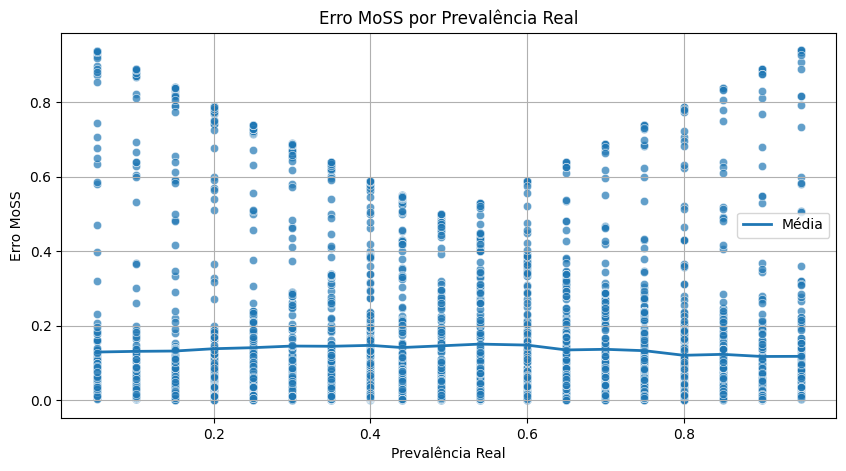

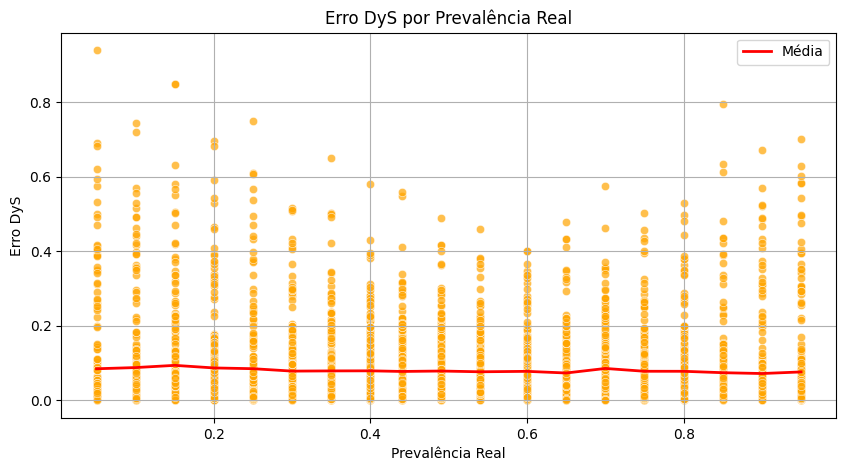

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
#  ERRO MOSS vs PREVALÊNCIA
# ============================

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="prevalencia_real", y="erro_moss", alpha=0.7)
sns.lineplot(data=df.groupby("prevalencia_real")["erro_moss"].mean(), label="Média", linewidth=2)

plt.title("Erro MoSS por Prevalência Real")
plt.xlabel("Prevalência Real")
plt.ylabel("Erro MoSS")
plt.grid(True)
plt.show()

# ============================
#  ERRO DyS vs PREVALÊNCIA
# ============================

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="prevalencia_real", y="erro_dys", alpha=0.7, color='orange')
sns.lineplot(data=df.groupby("prevalencia_real")["erro_dys"].mean(), label="Média", linewidth=2, color='red')

plt.title("Erro DyS por Prevalência Real")
plt.xlabel("Prevalência Real")
plt.ylabel("Erro DyS")
plt.grid(True)
plt.show()


In [17]:
df["gap_dys"] = df["erro_moss"] - df["erro_dys"]
df.sort_values("gap_dys", ascending=False).head(999)
df.to_csv("gap.csv")

In [ ]:
df_num = df.select_dtypes(include=["number"])
df_num.corr()["erro_moss"]["prevalencia_real"]

np.float64(-0.023834622695402784)

In [8]:
corr = df_num.corr()

print("Erro MoSS × Variância dos Scores:", corr.loc["erro_moss", "var_scores"])
print("Erro MoSS × Entropia:", corr.loc["erro_moss", "entropy"])
print("Erro MoSS × Erro DyS:", corr.loc["erro_moss", "erro_dys"])


Erro MoSS × Variância dos Scores: -0.45208945325175687
Erro MoSS × Entropia: 0.3918179840738348
Erro MoSS × Erro DyS: 0.6706242353734224


In [12]:
import numpy as np
import pandas as pd
import os
import pickle
import warnings
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

warnings.filterwarnings("ignore")

# ============================================================
# ========= FEATURE EXTRACTION (BASELINE A) ===================
# ============================================================

FEATURE_ORDER_BASE = [
    'mean', 'var', 'skew', 'kurt',
    'q10', 'q25', 'q50', 'q75', 'q90',
    'entropy'
]

def extract_features_base(scores):
    scores = np.ravel(scores)

    feats = {
        'mean': np.mean(scores),
        'var': np.var(scores),
        'skew': skew(scores),
        'kurt': kurtosis(scores),
        'q10': np.quantile(scores, 0.1),
        'q25': np.quantile(scores, 0.25),
        'q50': np.quantile(scores, 0.5),
        'q75': np.quantile(scores, 0.75),
        'q90': np.quantile(scores, 0.9),
    }

    hist, _ = np.histogram(scores, bins=20, density=True)
    hist += 1e-12
    feats["entropy"] = entropy(hist)

    return np.array([feats[k] for k in FEATURE_ORDER_BASE])


# ============================================================
# ========= NOVAS FEATURES (B) ===============================
# ============================================================

def extract_features_new(scores):
    scores = np.ravel(scores)
    f_min = np.min(scores)
    f_max = np.max(scores)
    f_range = f_max - f_min
    f_std = np.std(scores)
    return np.array([f_min, f_max, f_range, f_std])

FEATURE_ORDER_NEW = ["min", "max", "range", "std"]


def extract_features_A(scores):
    return extract_features_base(scores)


def extract_features_B(scores):
    base = extract_features_base(scores)
    new = extract_features_new(scores)
    return np.concatenate([base, new])


# ============================================================
# ====================== APP SAMPLING =========================
# ============================================================

def generate_artificial_prevalences(n_prev=19, repeats=2):
    prevalences = np.linspace(0.05, 0.95, n_prev)
    return [[1-p, p] for p in prevalences] * repeats

def sample_with_prevalence(y, prevalence, batch_size):
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    n_pos = int(batch_size * prevalence[1])
    n_neg = batch_size - n_pos
    pos = np.random.choice(pos_idx, n_pos, replace=True)
    neg = np.random.choice(neg_idx, n_neg, replace=True)
    idx = np.concatenate([pos, neg])
    np.random.shuffle(idx)
    return idx

class APP:
    def __init__(self, batch_size=100, n_prev=19, repeats=2, seed=42):
        self.batch_size = batch_size
        self.prevalences = generate_artificial_prevalences(n_prev, repeats)
        np.random.seed(seed)

    def split(self, X, y):
        for prev in self.prevalences:
            idx = sample_with_prevalence(y, prev, self.batch_size)
            yield idx, prev


# ============================================================
# ======================== DyS ===============================
# ============================================================

def hellinger_distance(p, q):
    p = p / (p.sum() + 1e-12)
    q = q / (q.sum() + 1e-12)
    return (1/np.sqrt(2)) * np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2))

def dys_quantifier(scores_batch, scores_train, y_train):
    pos_scores = scores_train[y_train == 1]
    neg_scores = scores_train[y_train == 0]

    h_batch, _ = np.histogram(scores_batch, bins=20, density=True)
    h_pos, _ = np.histogram(pos_scores, bins=20, density=True)
    h_neg, _ = np.histogram(neg_scores, bins=20, density=True)

    def mixture(prev):
        return (1-prev)*h_neg + prev*h_pos

    grid = np.linspace(0,1,1001)
    best_prev = min(grid, key=lambda p: hellinger_distance(h_batch, mixture(p)))
    return float(best_prev)


# ============================================================
# =============== TREINAR REGRESSOR MOSS A/B =================
# ============================================================

def load_moss_regressor_AB(pkl_path):
    with open(pkl_path, "rb") as f:
        synthetic_dists = pickle.load(f)

    XA, XB, Y = [], [], []

    for key, curves in synthetic_dists.items():
        all_scores = np.vstack(curves)[:, 0]

        featsA = extract_features_A(all_scores)
        featsB = extract_features_B(all_scores)

        XA.append(featsA)
        XB.append(featsB)

        Y.append(key[0] if isinstance(key, tuple) else key)

    XA = np.vstack(XA)
    XB = np.vstack(XB)
    Y = np.array(Y)

    regA = RandomForestRegressor(n_estimators=300, random_state=42)
    regB = RandomForestRegressor(n_estimators=300, random_state=42)

    regA.fit(XA, Y)
    regB.fit(XB, Y)

    return regA, regB


# ============================================================
# ============== AVALIAÇÃO REAL DATASETS =====================
# ============================================================

def load_csv_dataset(path):
    df = pd.read_csv(path)
    if "y" in df.columns:
        y = df["y"].values
        X = df.drop(columns=["y"]).values
    else:
        y = df.iloc[:, -1].values
        X = df.iloc[:, :-1].values
    if len(np.unique(y)) > 2:
        y = (y == np.max(y)).astype(int)
    return X, y


def avaliar_dataset_AB(ds_name, regA, regB, app, root):
    path = os.path.join(root, ds_name)
    X, y = load_csv_dataset(path)

    X = StandardScaler().fit_transform(X)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.5,
                                          random_state=42, stratify=y)

    clf = RandomForestClassifier(n_estimators=300, random_state=42)
    clf.fit(Xtr, ytr)

    train_scores = clf.predict_proba(Xtr)[:, 1]
    rows = []

    for idx, prev_real in app.split(Xte, yte):
        Xb = Xte[idx]
        yb = yte[idx]
        scores = clf.predict_proba(Xb)[:, 1]

        # MOSS BASE
        featsA = extract_features_A(scores)
        prevA = regA.predict(featsA.reshape(1, -1))[0]

        # MOSS NOVO
        featsB = extract_features_B(scores)
        prevB = regB.predict(featsB.reshape(1, -1))[0]

        # DyS
        prev_dys = dys_quantifier(scores_batch=scores,
                                  scores_train=train_scores,
                                  y_train=ytr)

        rows.append({
            "dataset": ds_name,
            "prevalencia_real": np.mean(yb),
            "prev_moss_A": prevA,
            "prev_moss_B": prevB,
            "erro_moss_A": abs(prevA - np.mean(yb)),
            "erro_moss_B": abs(prevB - np.mean(yb)),
            "erro_dys": abs(prev_dys - np.mean(yb)),
            "n_amostras": len(yb),
            "var_scores": np.var(scores),
            "entropy": extract_features_base(scores)[-1]
        })

    return rows


# ============================================================
# ====================== LOOP GLOBAL ==========================
# ============================================================

moss_folder = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss"
datasets_root = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary"

pkls = [
    os.path.join(moss_folder, f)
    for f in os.listdir(moss_folder)
    if f.endswith(".pkl") and "gigante" in f.lower()
]

datasets = sorted([f for f in os.listdir(datasets_root) if f.endswith(".csv")])

app = APP(batch_size=100, n_prev=19, repeats=2, seed=42)

all_rows = []

for pkl_path in pkls:
    print(f"\nTreinando regressor A/B com {pkl_path}")
    regA, regB = load_moss_regressor_AB(pkl_path)

    for ds in datasets:
        print(f"→ Dataset: {ds}")
        rows = avaliar_dataset_AB(ds, regA, regB, app, datasets_root)
        all_rows.extend(rows)

df = pd.DataFrame(all_rows)
df.to_csv("tabela_final_AB.csv", index=False)

print("\nTabela salva como tabela_final_AB.csv")


Treinando regressor A/B com /var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss/moss_GIGANTE.pkl
→ Dataset: 1460_banana.csv
→ Dataset: 1462_banknote-authentication.csv
→ Dataset: 1466_cardiotocography.csv
→ Dataset: 1475_first-order-theorem-proving.csv
→ Dataset: 1479_hill-valley.csv
→ Dataset: 1485_madelon.csv
→ Dataset: 1489_phoneme.csv
→ Dataset: 1494_qsar-biodeg.csv
→ Dataset: 1496_ringnorm.csv
→ Dataset: 1497_wall-robot-navigation.csv
→ Dataset: 1504_steel-plates-fault.csv
→ Dataset: 1507_twonorm.csv
→ Dataset: 1526_wall-robot-navigation.csv
→ Dataset: 1535_volcanoes-b5.csv
→ Dataset: 1538_volcanoes-d1.csv
→ Dataset: 1539_volcanoes-d2.csv
→ Dataset: 1540_volcanoes-d3.csv
→ Dataset: 1541_volcanoes-d4.csv
→ Dataset: 1566_hill-valley.csv
→ Dataset: 182_satimage.csv
→ Dataset: 23_cmc.csv
→ Dataset: 28_optdigits.csv
→ Dataset: 294_satellite_image.csv
→ Dataset: 30_page-blocks.csv
→ Dataset: 312_scene.csv
→ Dataset: 375_JapaneseVowels.csv
→ Dataset: 40733_yeast.csv
→ Dataset: 4

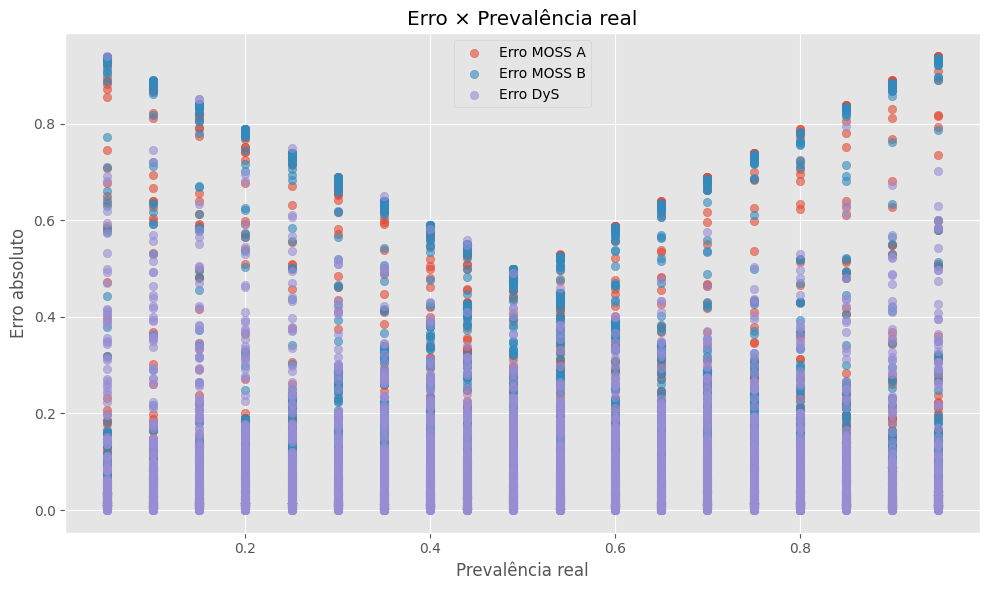

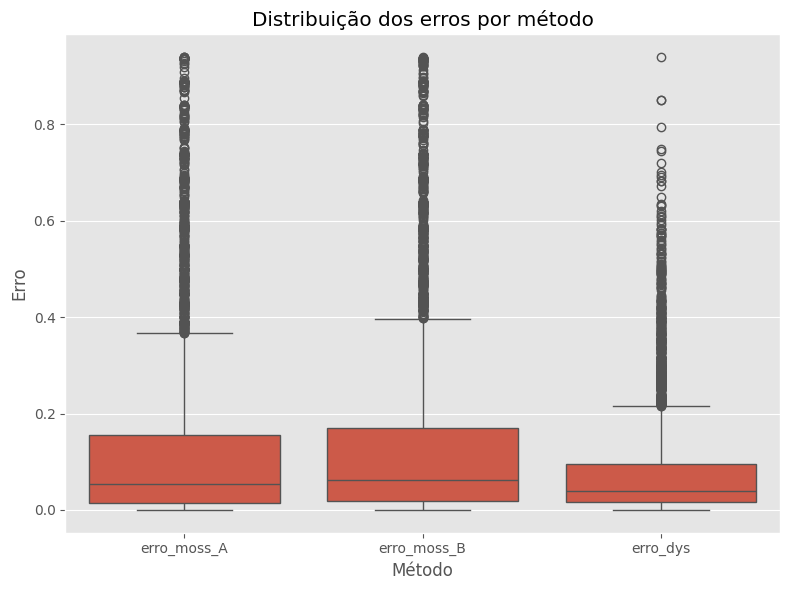

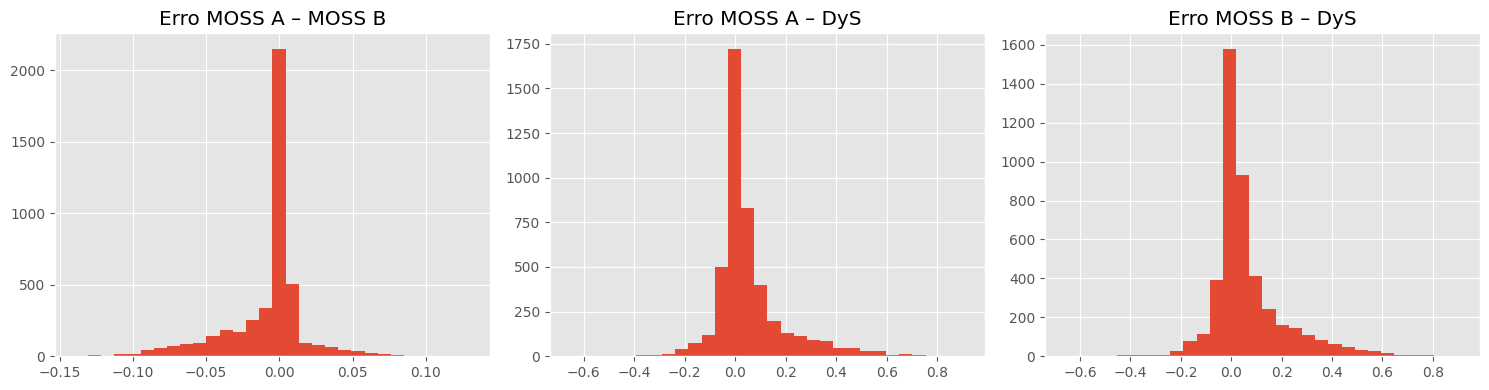

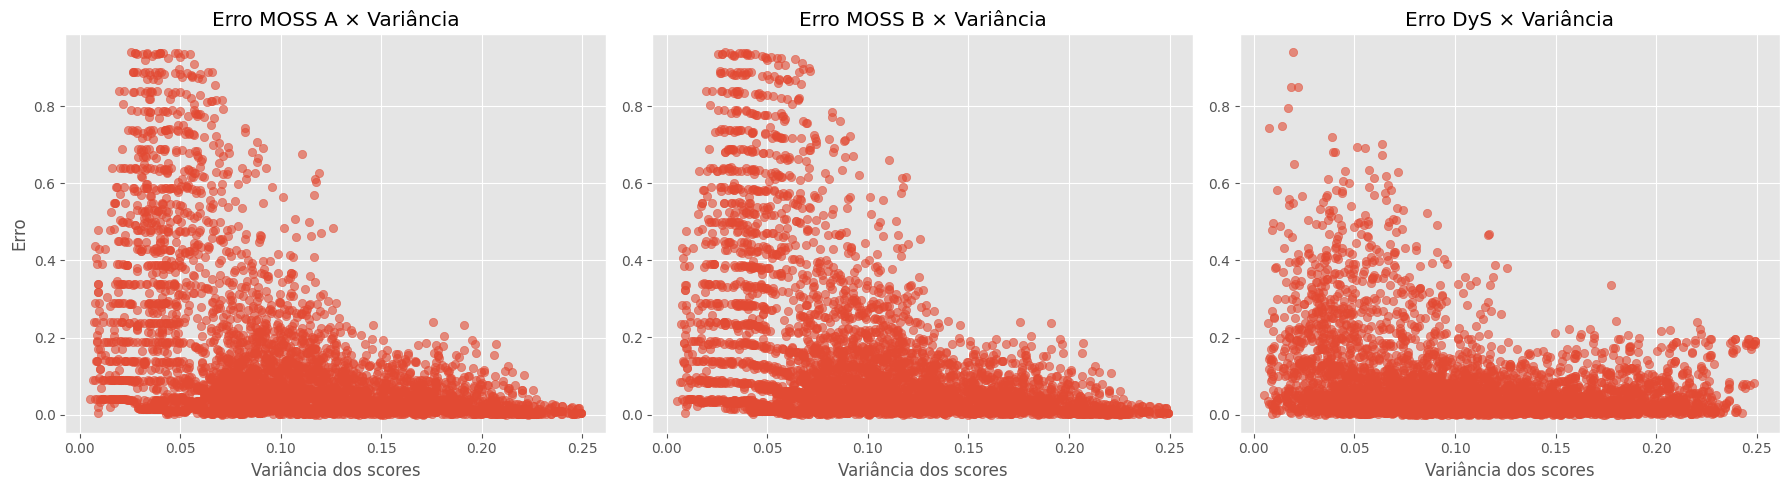

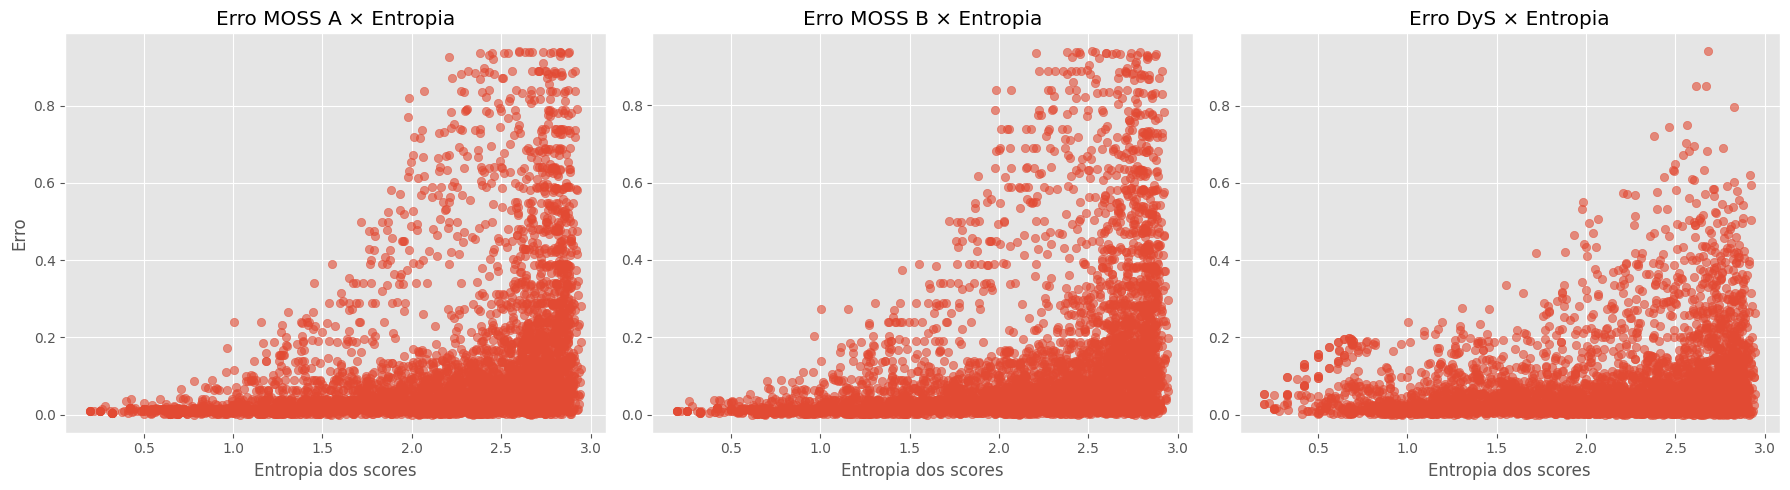

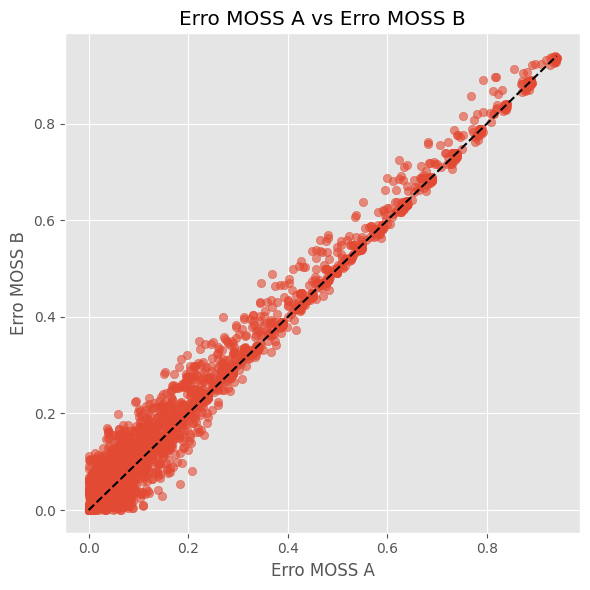

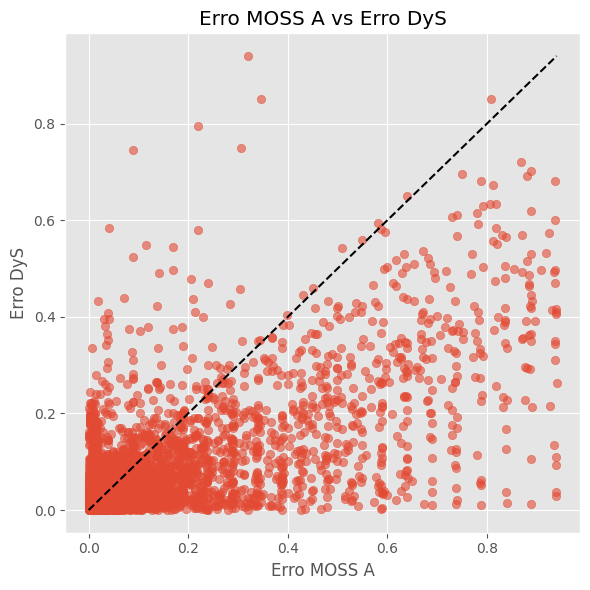

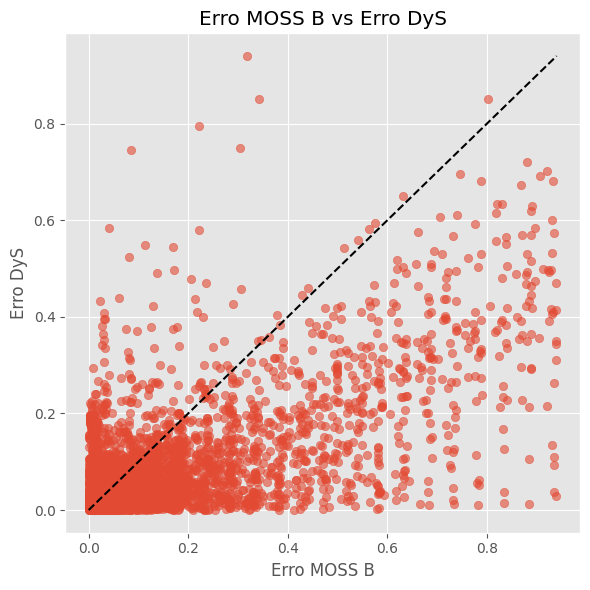

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("tabela_final_AB.csv")

# ============================
# 1. ERRO × PREVALÊNCIA
# ============================

plt.figure(figsize=(10,6))
plt.scatter(df["prevalencia_real"], df["erro_moss_A"], label="Erro MOSS A", alpha=0.6)
plt.scatter(df["prevalencia_real"], df["erro_moss_B"], label="Erro MOSS B", alpha=0.6)
plt.scatter(df["prevalencia_real"], df["erro_dys"], label="Erro DyS", alpha=0.6)
plt.xlabel("Prevalência real")
plt.ylabel("Erro absoluto")
plt.legend()
plt.title("Erro × Prevalência real")
plt.tight_layout()
plt.show()


# ============================
# 2. BOXPLOT DOS ERROS
# ============================

plt.figure(figsize=(8,6))
df_melt = df[["erro_moss_A", "erro_moss_B", "erro_dys"]].melt(var_name="Método", value_name="Erro")
sns.boxplot(data=df_melt, x="Método", y="Erro")
plt.title("Distribuição dos erros por método")
plt.tight_layout()
plt.show()


# ============================
# 3. HISTOGRAMAS DE DIFERENÇA DE ERRO
# ============================

df["dif_A_B"] = df["erro_moss_A"] - df["erro_moss_B"]
df["dif_A_DyS"] = df["erro_moss_A"] - df["erro_dys"]
df["dif_B_DyS"] = df["erro_moss_B"] - df["erro_dys"]

fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].hist(df["dif_A_B"], bins=30)
axes[0].set_title("Erro MOSS A – MOSS B")

axes[1].hist(df["dif_A_DyS"], bins=30)
axes[1].set_title("Erro MOSS A – DyS")

axes[2].hist(df["dif_B_DyS"], bins=30)
axes[2].set_title("Erro MOSS B – DyS")

plt.tight_layout()
plt.show()


# ============================
# 4. CORRELAÇÃO ERROS × FEATURES
# ============================

fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].scatter(df["var_scores"], df["erro_moss_A"], alpha=0.6)
axes[0].set_xlabel("Variância dos scores")
axes[0].set_ylabel("Erro")
axes[0].set_title("Erro MOSS A × Variância")

axes[1].scatter(df["var_scores"], df["erro_moss_B"], alpha=0.6)
axes[1].set_xlabel("Variância dos scores")
axes[1].set_title("Erro MOSS B × Variância")

axes[2].scatter(df["var_scores"], df["erro_dys"], alpha=0.6)
axes[2].set_xlabel("Variância dos scores")
axes[2].set_title("Erro DyS × Variância")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].scatter(df["entropy"], df["erro_moss_A"], alpha=0.6)
axes[0].set_xlabel("Entropia dos scores")
axes[0].set_ylabel("Erro")
axes[0].set_title("Erro MOSS A × Entropia")

axes[1].scatter(df["entropy"], df["erro_moss_B"], alpha=0.6)
axes[1].set_xlabel("Entropia dos scores")
axes[1].set_title("Erro MOSS B × Entropia")

axes[2].scatter(df["entropy"], df["erro_dys"], alpha=0.6)
axes[2].set_xlabel("Entropia dos scores")
axes[2].set_title("Erro DyS × Entropia")

plt.tight_layout()
plt.show()


# ============================
# 5. COMPARAÇÃO DIRETA DE ERROS
# ============================

def scatter_45(x, y, labelx, labely):
    plt.figure(figsize=(6,6))
    plt.scatter(df[x], df[y], alpha=0.6)
    lims = [0, max(df[x].max(), df[y].max())]
    plt.plot(lims, lims, 'k--')
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.title(f"{labelx} vs {labely}")
    plt.tight_layout()
    plt.show()

scatter_45("erro_moss_A", "erro_moss_B", "Erro MOSS A", "Erro MOSS B")
scatter_45("erro_moss_A", "erro_dys",    "Erro MOSS A", "Erro DyS")
scatter_45("erro_moss_B", "erro_dys",    "Erro MOSS B", "Erro DyS")
